<div style="text-align: center">
    <h2><font size=6>MODELO 4 - DENSENET</font></h2>
</d>
</div>

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import numpy as np

In [4]:
train_dir = "dataset_final/train"
val_dir = "dataset_final/validation"
test_dir = "dataset_final/test"

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4455 images belonging to 6 classes.
Found 952 images belonging to 6 classes.
Found 959 images belonging to 6 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())

**Cargar modelo DenseNet121**

In [6]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
for layer in base_model.layers:
    layer.trainable = False

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(6, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,305,542 (27.87 MB)

 Trainable params: 265,990 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [11]:
EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/30


C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


140/140 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.3861 - loss: 1.6200 - val_accuracy: 0.6502 - val_loss: 1.0025
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.6434 - loss: 1.0085 - val_accuracy: 0.7006 - val_loss: 0.8399
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.6715 - loss: 0.9108 - val_accuracy: 0.7174 - val_loss: 0.7797
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7132 - loss: 0.8055 - val_accuracy: 0.7290 - val_loss: 0.7363
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.7367 - loss: 0.7615 - val_accuracy: 0.7468 - val_loss: 0.7060
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7490 - loss: 0.7154 - val_accuracy: 0.7405 - val_loss: 0.6915
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7588 - loss: 0.6852 - val_accuracy: 0.7532 - val_loss: 0.6699
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.7550 - loss: 0.6707 - val_accuracy: 0.760

In [12]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

30/30 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.7822 - loss: 0.6424
Test Loss: 0.543033242225647
Test Accuracy: 0.8185610175132751


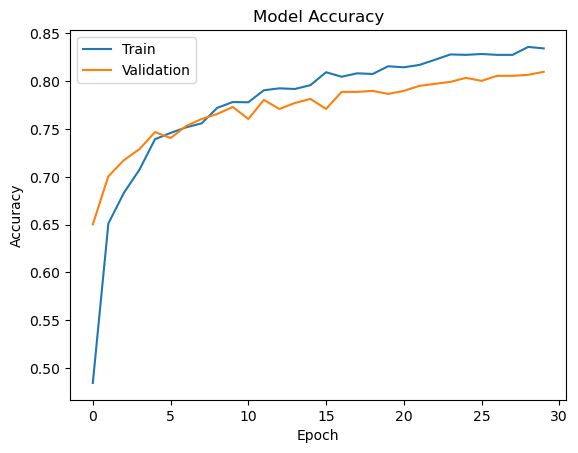

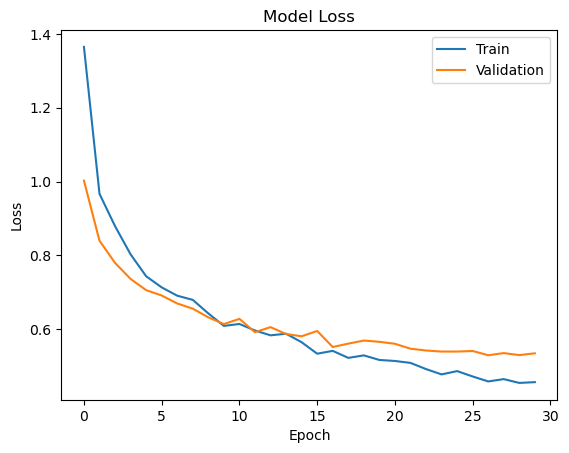

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [14]:
model.save("modelo_densenet121.h5")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
model = load_model("modelo_densenet121.h5")

In [7]:

predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(test_generator.class_indices)

30/30 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step
{'AgeDegeneration': 0, 'Myopia': 1, 'cataract': 2, 'diabetic_retinopathy': 3, 'glaucoma': 4, 'healthy': 5}


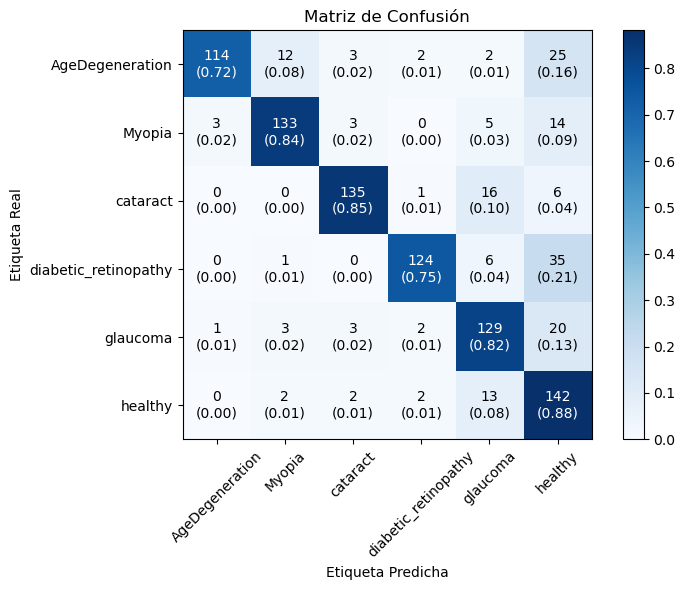

In [8]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Matriz de Confusión")
plt.colorbar()

tick_marks = np.arange(len(class_labels))

plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

thresh = conf_matrix_normalized.max() / 2.

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):

        absolute_value = conf_matrix[i, j]
        percentage_value = conf_matrix_normalized[i, j]

        plt.text(j, i,
                 f"{absolute_value}\n({percentage_value:.2f})",
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if percentage_value > thresh else "black")

plt.ylabel("Etiqueta Real")
plt.xlabel("Etiqueta Predicha")

plt.tight_layout()
plt.show()

In [9]:
print("Reporte de Clasificación:")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

Reporte de Clasificación:
                      precision    recall  f1-score   support

     AgeDegeneration       0.97      0.72      0.83       158
              Myopia       0.88      0.84      0.86       158
            cataract       0.92      0.85      0.89       158
diabetic_retinopathy       0.95      0.75      0.84       166
            glaucoma       0.75      0.82      0.78       158
             healthy       0.59      0.88      0.70       161

            accuracy                           0.81       959
           macro avg       0.84      0.81      0.82       959
        weighted avg       0.84      0.81      0.82       959



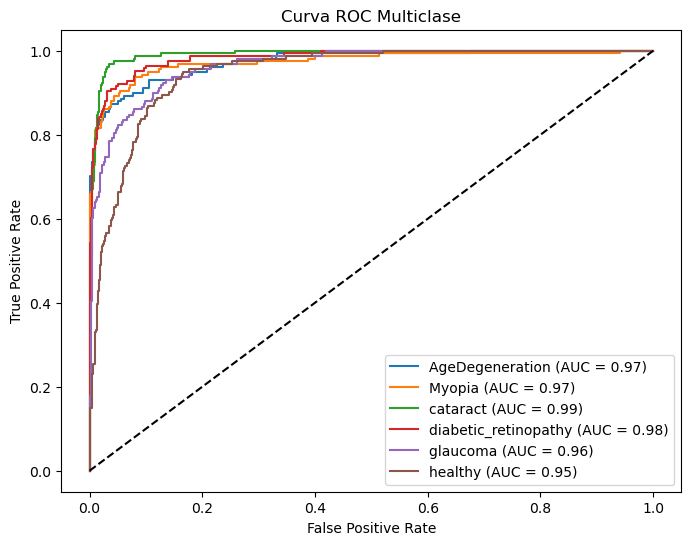

In [10]:
y_true_bin = label_binarize(true_classes, classes=range(len(class_labels)))

plt.figure(figsize=(8,6))

for i in range(len(class_labels)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], predictions[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Curva ROC Multiclase")

plt.legend()

plt.show()